<a href="https://colab.research.google.com/github/aiska28/Data-Maining/blob/main/Life_Expectancy_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Life Expectancy Data.csv to Life Expectancy Data.csv


In [3]:
data = pd.read_csv("Life Expectancy Data.csv")
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
data.isnull().sum()

data = data.fillna(data.mean(numeric_only=True))

In [5]:
data = data.drop(['Country', 'Status'], axis=1)

In [8]:
X = data.drop('Life expectancy ', axis=1)
y = data['Life expectancy ']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 2.861247137426959
MSE: 15.360886871198257
R2 Score: 0.8226947795455832


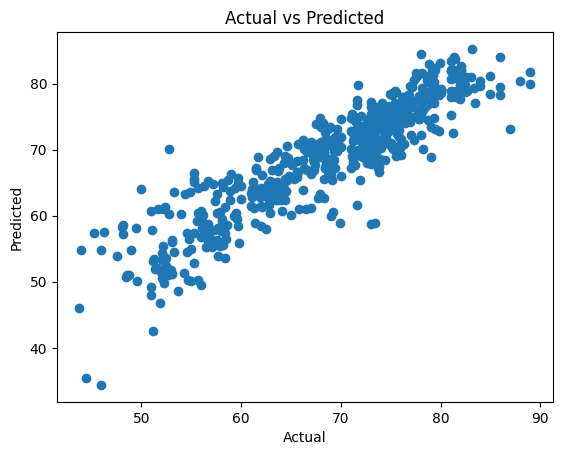

In [13]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [14]:
print("Intercept:", model.intercept_)
print("Koefisien:", model.coef_)

Intercept: 67.54564066368084
Koefisien: [-6.17161413e-03 -2.11896729e-02  9.67468708e-02  1.17478946e-01
  1.15058850e-04 -1.70201135e-02 -2.40831040e-05  3.94296953e-02
 -7.18203902e-02  2.79189288e-02  6.11631096e-02  4.03653404e-02
 -4.62137531e-01  3.75196647e-05 -1.01366386e-09 -9.85596608e-02
  6.86161777e-03  6.65446186e+00  6.50872362e-01]


In [16]:
coef_data = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coef_data)

                            Feature   Coefficient
0                              Year -6.171614e-03
1                   Adult Mortality -2.118967e-02
2                     infant deaths  9.674687e-02
3                           Alcohol  1.174789e-01
4            percentage expenditure  1.150589e-04
5                       Hepatitis B -1.702011e-02
6                          Measles  -2.408310e-05
7                              BMI   3.942970e-02
8                under-five deaths  -7.182039e-02
9                             Polio  2.791893e-02
10                Total expenditure  6.116311e-02
11                      Diphtheria   4.036534e-02
12                         HIV/AIDS -4.621375e-01
13                              GDP  3.751966e-05
14                       Population -1.013664e-09
15             thinness  1-19 years -9.855966e-02
16               thinness 5-9 years  6.861618e-03
17  Income composition of resources  6.654462e+00
18                        Schooling  6.508724e-01


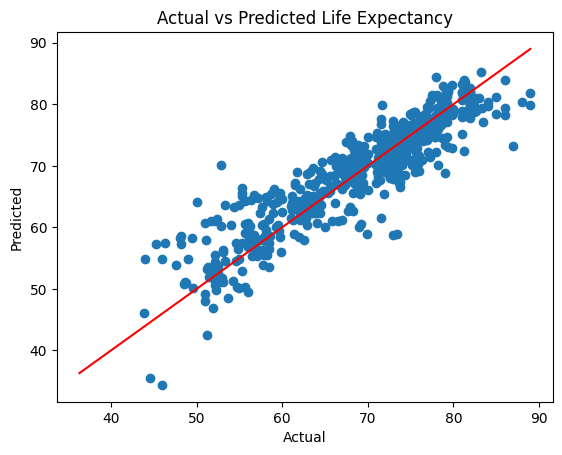

In [17]:
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Life Expectancy")
plt.show()